# 11 — Feature Importance & Analisis de Errores

Analisis del **Modelo 05 (RS Embeddings + Metadata)** — el mejor modelo del proyecto con R²≈0.79.

**Objetivos:**
1. **Feature Importance**: que features impulsan la prediccion de exito en ventas (total reviews)?
2. **Analisis de errores**: en que tipos de juegos falla el modelo?

Se usa la importancia nativa de XGBoost (gain/cover/weight) que mide la contribucion de cada feature al reducir el error en los arboles de decision.

El modelo predice `total_reviews` como proxy de exito comercial de un videojuego.

In [1]:
import sys, os, ast, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
warnings.filterwarnings('ignore')

BASE        = os.path.abspath('..')
DATA        = os.path.join(BASE, 'Data')
ITEM_EMB    = os.path.join(DATA, 'item_embeddings_rs_clean.npy')
ITEMMAP     = os.path.join(DATA, 'item2idx.json')
STEAM_GAMES = os.path.join(DATA, 'steam_games.json')

print('Librerias cargadas OK')

Librerias cargadas OK


## 1. Carga de Datos

Mismo pipeline que el Modelo 05 (RS Embeddings + Metadata, 70 dimensiones).

In [2]:
item_emb = np.load(ITEM_EMB)

with open(ITEMMAP, 'r') as f:
    item2idx = {k: int(v) for k, v in json.load(f).items()}

games = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            games.append(ast.literal_eval(line))

df_games = pd.json_normalize(games).rename(columns={'id': 'item_id'})
df_games['item_idx'] = df_games['item_id'].map(item2idx)
df_games = df_games.dropna(subset=['item_idx'])
df_games['item_idx'] = df_games['item_idx'].astype(int)
df_games['release_date_parsed'] = pd.to_datetime(df_games['release_date'], errors='coerce')

def clean_price(p):
    if pd.isna(p) or p == 'Free' or p == '':
        return 0.0
    try:
        return float(str(p).replace('$', '').replace(',', '').strip())
    except Exception:
        return 0.0

df_games['price']         = df_games['price'].apply(clean_price)
df_games['early_access']  = df_games['early_access'].fillna(False).astype(int)
df_games['num_genres']    = df_games['genres'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_games['num_tags']      = df_games['tags'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_games['num_specs']     = df_games['specs'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_games['has_sentiment'] = df_games['sentiment'].notna().astype(int) if 'sentiment' in df_games.columns else 0

# Target: total reviews por juego (mismo que Modelo 05)
INTERACTIONS = os.path.join(DATA, 'interactions.parquet')
df_inter = pd.read_parquet(INTERACTIONS)
target_arr = df_inter.groupby('item_idx').size().reindex(range(len(item_emb))).fillna(0).values.astype(float)

print(f'Embeddings   : {item_emb.shape}')
print(f'Games loaded : {len(df_games)}')
print(f'Target range : {int(target_arr.min())} - {int(target_arr.max())}')

Embeddings   : (3682, 64)
Games loaded : 3195
Target range : 1 - 3759


In [3]:
META_COLS  = ['price', 'early_access', 'num_genres', 'num_tags', 'num_specs', 'has_sentiment']
FEAT_NAMES = [f'rs_{i}' for i in range(64)] + META_COLS

meta = df_games.set_index('item_idx').reindex(range(len(item_emb)))
meta_features = meta[META_COLS].fillna(0).values

# Usar DataFrame con nombres de features para que get_score() retorne nombres correctos
X = pd.DataFrame(np.hstack([item_emb, meta_features]), columns=FEAT_NAMES)
y = target_arr.astype(float)

cutoff = pd.Timestamp('2016-01-01')
item_dates = meta['release_date_parsed'].values

train_mask = np.array([pd.notna(d) and d < cutoff for d in item_dates])
test_mask  = np.array([pd.notna(d) and d >= cutoff for d in item_dates])

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

test_meta = meta[test_mask].copy()
test_meta['y_true'] = y_test

print(f'Train: {X_train.shape[0]} juegos | Test: {X_test.shape[0]} juegos')
print(f'Features: {X.shape[1]} dim (64 RS + {len(META_COLS)} metadata)')

Train: 2621 juegos | Test: 486 juegos
Features: 70 dim (64 RS + 6 metadata)


In [4]:
# Hiperparametros del Modelo 05 obtenidos con Optuna (fijados para reproducibilidad)
best_params = {
    'n_estimators'    : 689,
    'learning_rate'   : 0.04063041897411419,
    'max_depth'       : 7,
    'min_child_weight': 2,
    'subsample'       : 0.593847617575133,
    'colsample_bytree': 0.7271079216264804,
    'gamma'           : 0.9242573079974742,
    'random_state'    : 42,
    'tree_method'     : 'hist',
    'verbosity'       : 0,
}

model = XGBRegressor(**best_params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
print(f'Modelo 05 — R2 = {r2:.4f} | RMSE = {rmse:.2f}')

test_meta = test_meta.copy()
test_meta['y_pred']  = y_pred
test_meta['error']   = y_pred - y_test
test_meta['abs_err'] = np.abs(y_pred - y_test)

Modelo 05 — R2 = 0.7922 | RMSE = 25.94


## 2. Feature Importance — XGBoost Nativo

Se usan tres metricas de importancia de XGBoost:
- **gain**: reduccion media de impureza al usar el feature (equivalente a SHAP global)
- **weight**: cuantas veces se usa el feature para hacer splits
- **cover**: numero de muestras cubiertas por los splits del feature

Importancia (gain) — RS embeddings : 100.0%
Importancia (gain) — Metadata      : 0.0%


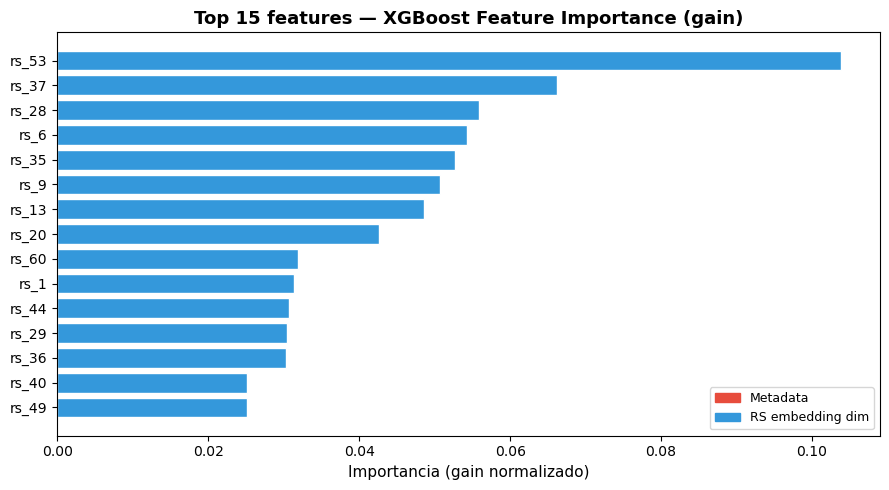

In [5]:
booster = model.get_booster()

# Obtener importancias por tipo
def get_importance_series(importance_type):
    scores = booster.get_score(importance_type=importance_type)
    s = pd.Series(scores).reindex(FEAT_NAMES).fillna(0)
    return s / s.sum()   # normalizar a [0,1]

imp_gain   = get_importance_series('gain')
imp_weight = get_importance_series('weight')
imp_cover  = get_importance_series('cover')

rs_total   = imp_gain[[f for f in FEAT_NAMES if f.startswith('rs_')]].sum()
meta_total = imp_gain[META_COLS].sum()
print(f'Importancia (gain) — RS embeddings : {rs_total*100:.1f}%')
print(f'Importancia (gain) — Metadata      : {meta_total*100:.1f}%')

# Top 15 features por gain
top15 = imp_gain.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if n in META_COLS else '#3498db' for n in top15.index]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importancia (gain normalizado)', fontsize=11)
ax.set_title('Top 15 features — XGBoost Feature Importance (gain)', fontsize=13, fontweight='bold')
legend_patches = [mpatches.Patch(color='#e74c3c', label='Metadata'),
                  mpatches.Patch(color='#3498db', label='RS embedding dim')]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.show()

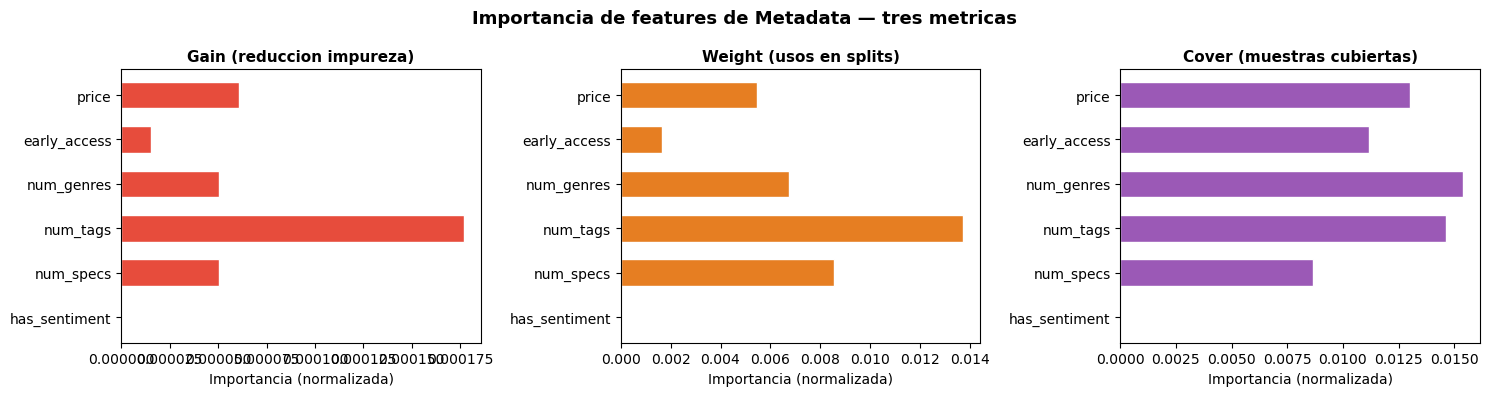

In [6]:
# Comparacion de las tres metricas de importancia para metadata
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles  = ['Gain (reduccion impureza)', 'Weight (usos en splits)', 'Cover (muestras cubiertas)']
imps    = [imp_gain[META_COLS], imp_weight[META_COLS], imp_cover[META_COLS]]
clrs    = ['#e74c3c', '#e67e22', '#9b59b6']

for ax, imp, title, clr in zip(axes, imps, titles, clrs):
    ax.barh(imp.index[::-1], imp.values[::-1], color=clr, edgecolor='white', height=0.6)
    ax.set_xlabel('Importancia (normalizada)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Importancia de features de Metadata — tres metricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

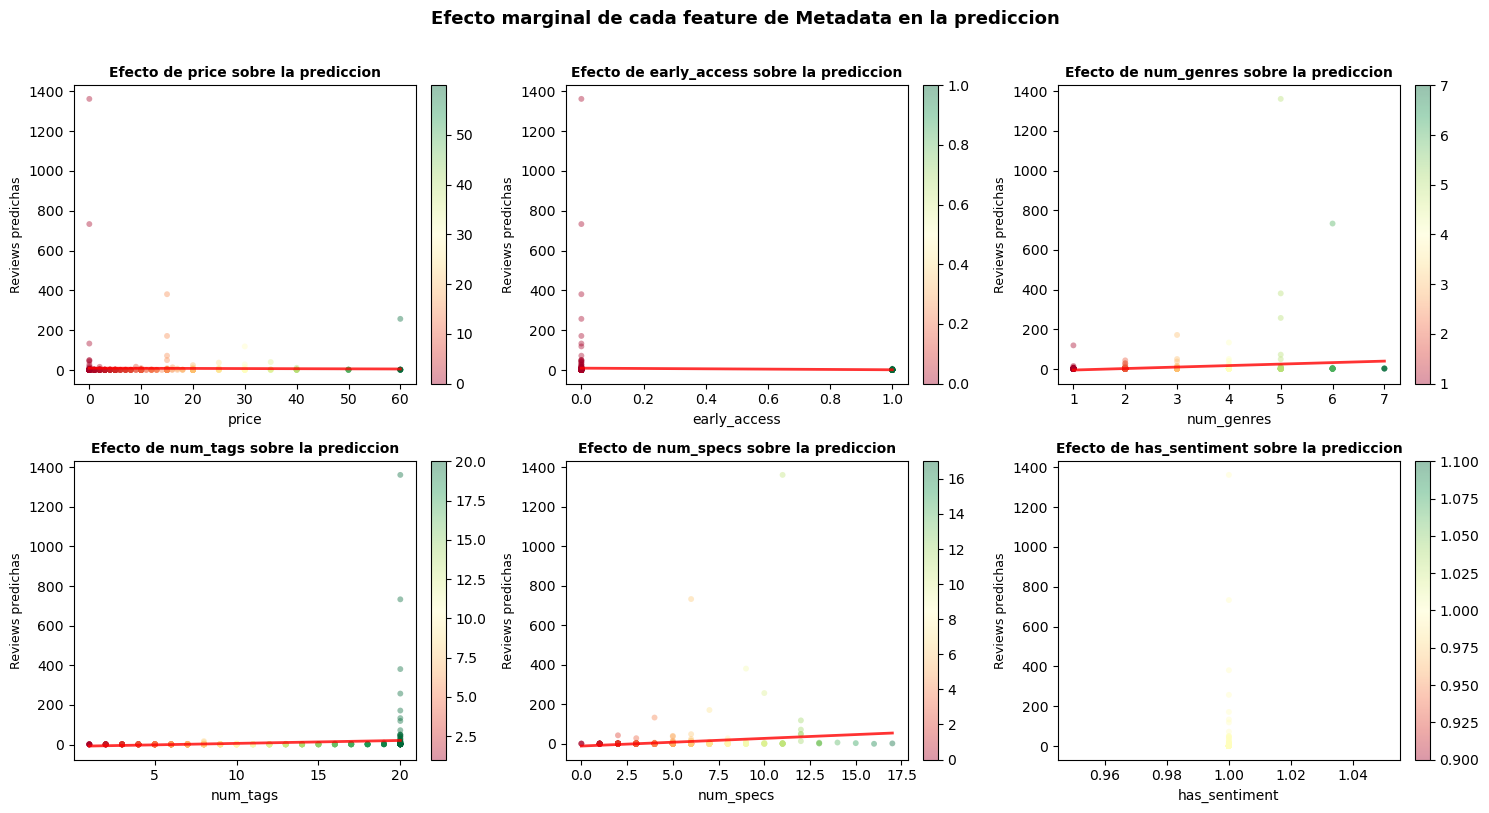

In [7]:
# Scatter: valor del feature vs prediccion (efecto marginal)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, feat in zip(axes, META_COLS):
    feat_vals = X_test[feat].values
    sc = ax.scatter(feat_vals, y_pred, alpha=0.4, s=18,
                    c=feat_vals, cmap='RdYlGn', edgecolors='none')
    # Tendencia
    order = np.argsort(feat_vals)
    from numpy.polynomial import polynomial as P
    if feat_vals.std() > 0:
        c = np.polyfit(feat_vals, y_pred, 1)
        xline = np.linspace(feat_vals.min(), feat_vals.max(), 100)
        ax.plot(xline, np.polyval(c, xline), 'r-', linewidth=2, alpha=0.8)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Reviews predichas', fontsize=9)
    ax.set_title(f'Efecto de {feat} sobre la prediccion', fontsize=10, fontweight='bold')
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Efecto marginal de cada feature de Metadata en la prediccion', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

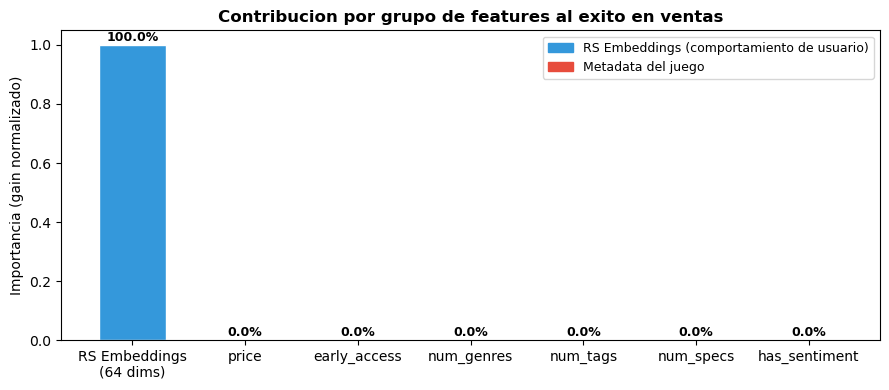

Interpretacion:
  Los RS embeddings explican el 100.0% de la importancia total
  La metadata explica el 0.0% restante
  Esto confirma que el COMPORTAMIENTO de los usuarios (RS) es el principal predictor del exito comercial


In [8]:
# Importancia agrupada: RS block vs cada feature de metadata
group_labels = ['RS Embeddings\n(64 dims)'] + META_COLS
group_values = [rs_total] + [imp_gain[c] for c in META_COLS]
colors_group = ['#3498db'] + ['#e74c3c'] * len(META_COLS)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(group_labels, group_values, color=colors_group, edgecolor='white', width=0.6)
for bar, val in zip(bars, group_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Importancia (gain normalizado)', fontsize=10)
ax.set_title('Contribucion por grupo de features al exito en ventas', fontsize=12, fontweight='bold')
legend_patches = [mpatches.Patch(color='#3498db', label='RS Embeddings (comportamiento de usuario)'),
                  mpatches.Patch(color='#e74c3c', label='Metadata del juego')]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.show()

print('Interpretacion:')
print(f'  Los RS embeddings explican el {rs_total*100:.1f}% de la importancia total')
print(f'  La metadata explica el {meta_total*100:.1f}% restante')
print(f'  Esto confirma que el COMPORTAMIENTO de los usuarios (RS) es el principal predictor del exito comercial')

## 3. Analisis de Errores

En que tipos de juegos falla el modelo? Analizamos los residuos segun precio, generos, tags y año de lanzamiento.

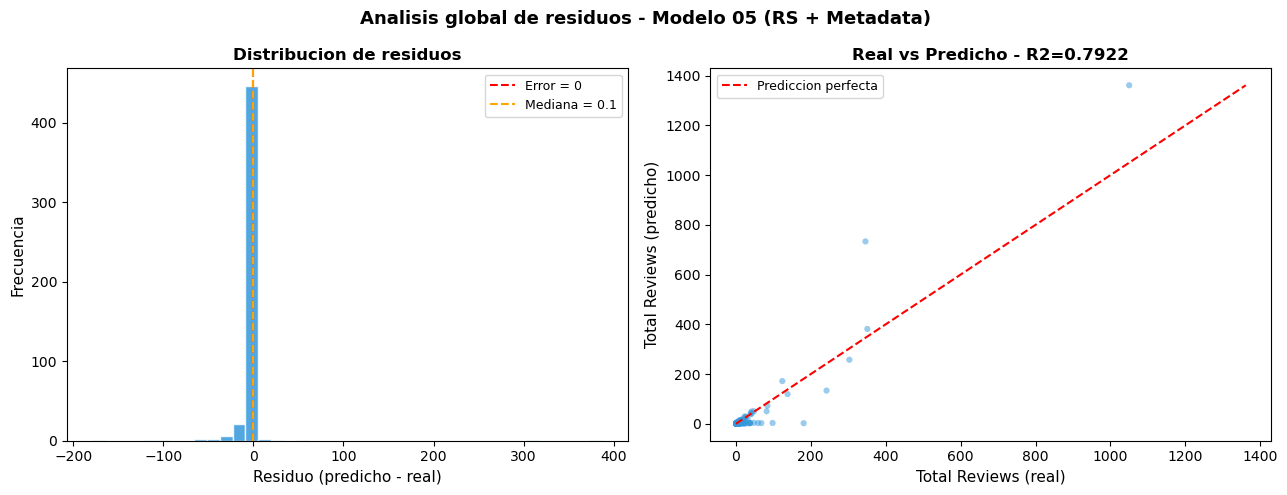

Sesgo medio (bias): -1.02 reviews
RMSE              : 25.94
Sub-estimados: 47.3%  |  Sobre-estimados: 52.7%


In [9]:
residuals = y_pred - y_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Error = 0')
axes[0].axvline(np.median(residuals), color='orange', linewidth=1.5, linestyle='--',
                label=f'Mediana = {np.median(residuals):.1f}')
axes[0].set_xlabel('Residuo (predicho - real)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribucion de residuos', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].scatter(y_test, y_pred, alpha=0.5, s=20, color='#3498db', edgecolors='none')
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Prediccion perfecta')
axes[1].set_xlabel('Total Reviews (real)', fontsize=11)
axes[1].set_ylabel('Total Reviews (predicho)', fontsize=11)
axes[1].set_title(f'Real vs Predicho - R2={r2:.4f}', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Analisis global de residuos - Modelo 05 (RS + Metadata)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Sesgo medio (bias): {residuals.mean():.2f} reviews')
print(f'RMSE              : {rmse:.2f}')
print(f'Sub-estimados: {(residuals < 0).mean()*100:.1f}%  |  Sobre-estimados: {(residuals > 0).mean()*100:.1f}%')

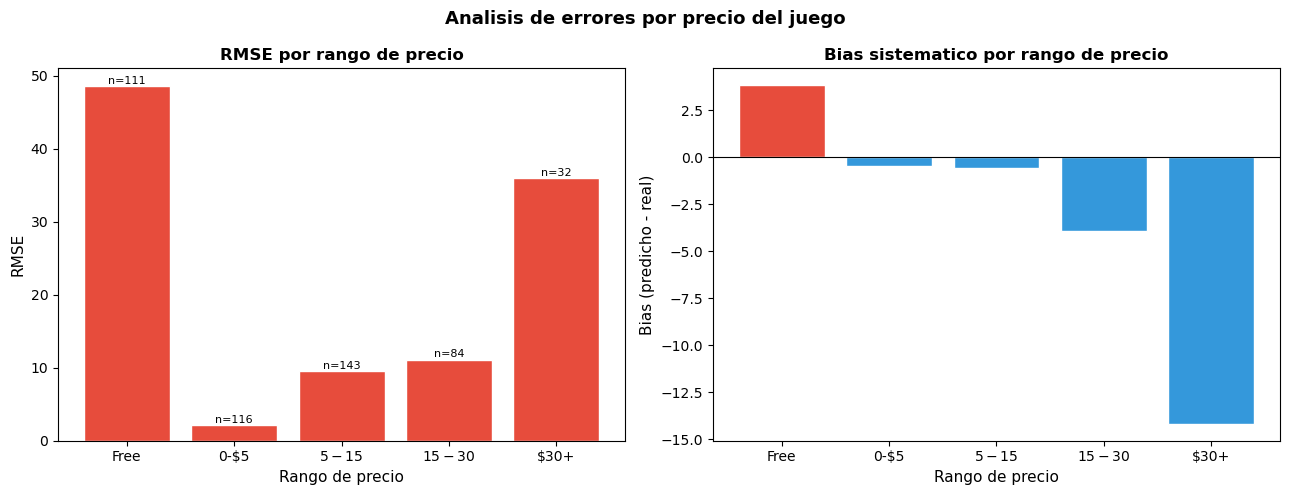

,price_range,n,rmse,bias
0,Free,111,48.556292,3.835771
1,0-$5,116,2.164573,-0.482221
2,$5-$15,143,9.524597,-0.578259
3,$15-$30,84,11.097374,-3.934758
4,$30+,32,35.964358,-14.177774


In [10]:
test_df = test_meta.reset_index().rename(columns={'index': 'item_idx'})
if 'item_idx' not in test_df.columns:
    test_df['item_idx'] = list(range(len(test_df)))

price_bins   = [-0.01, 0, 5, 15, 30, 1000]
price_labels = ['Free', '0-$5', '$5-$15', '$15-$30', '$30+']
test_df['price_range'] = pd.cut(test_df['price'], bins=price_bins, labels=price_labels)

price_stats = test_df.groupby('price_range', observed=True).agg(
    n=('y_true', 'count'),
    rmse=('error', lambda e: float(np.sqrt((e**2).mean()))),
    bias=('error', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(price_stats['price_range'].astype(str), price_stats['rmse'],
            color='#e74c3c', edgecolor='white')
axes[0].set_xlabel('Rango de precio', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('RMSE por rango de precio', fontsize=12, fontweight='bold')
for i, row in price_stats.iterrows():
    axes[0].text(i, row['rmse'] + 0.3, f"n={int(row['n'])}", ha='center', fontsize=8)

bias_colors = ['#e74c3c' if b > 0 else '#3498db' for b in price_stats['bias']]
axes[1].bar(price_stats['price_range'].astype(str), price_stats['bias'],
            color=bias_colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Rango de precio', fontsize=11)
axes[1].set_ylabel('Bias (predicho - real)', fontsize=11)
axes[1].set_title('Bias sistematico por rango de precio', fontsize=12, fontweight='bold')

plt.suptitle('Analisis de errores por precio del juego', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
display(price_stats)

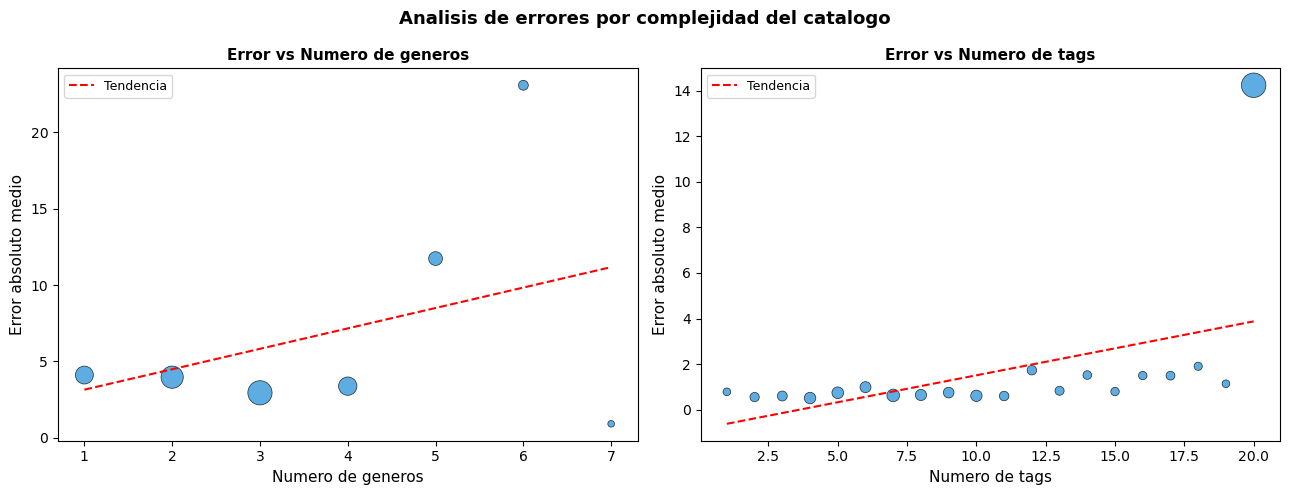

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in zip(axes, ['num_genres', 'num_tags'], ['Numero de generos', 'Numero de tags']):
    grp = test_df.groupby(col)['abs_err'].agg(['mean', 'count']).reset_index()
    grp = grp[grp['count'] >= 3]
    ax.scatter(grp[col], grp['mean'], s=grp['count'] * 2 + 15,
               color='#3498db', alpha=0.8, edgecolors='k', linewidth=0.5)
    if len(grp) > 2:
        z = np.polyfit(grp[col], grp['mean'], 1)
        xline = np.linspace(grp[col].min(), grp[col].max(), 100)
        ax.plot(xline, np.poly1d(z)(xline), 'r--', linewidth=1.5, label='Tendencia')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Error absoluto medio', fontsize=11)
    ax.set_title(f'Error vs {label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Analisis de errores por complejidad del catalogo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

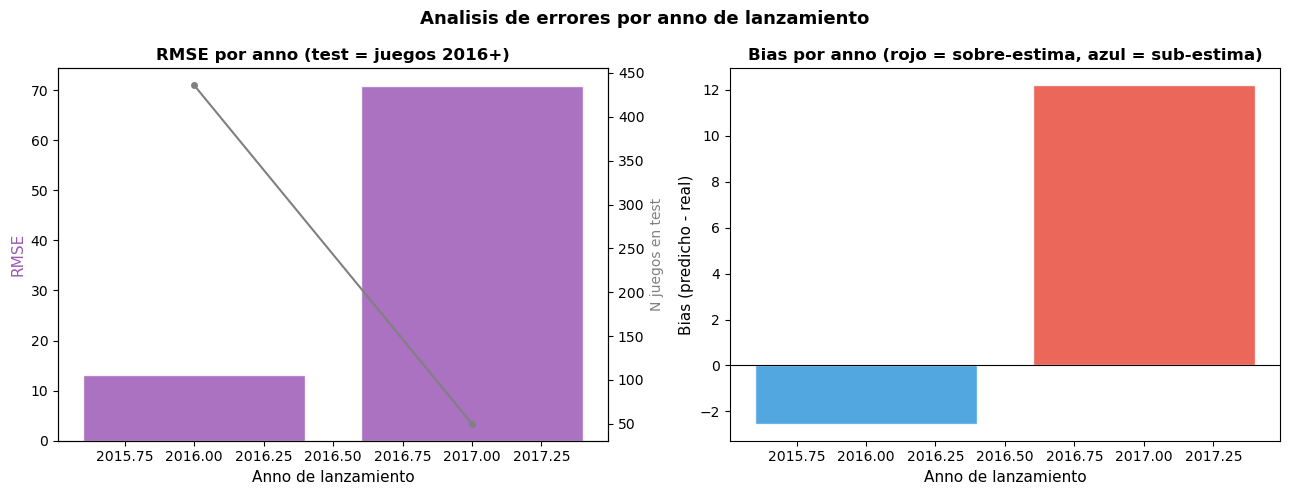

In [12]:
test_df['release_year'] = pd.to_datetime(test_df['release_date_parsed']).dt.year

year_stats = test_df.groupby('release_year').agg(
    n=('y_true', 'count'),
    rmse=('error', lambda e: float(np.sqrt((e**2).mean()))),
    bias=('error', 'mean'),
).reset_index()
year_stats = year_stats[year_stats['n'] >= 3]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(year_stats['release_year'], year_stats['rmse'],
            color='#9b59b6', edgecolor='white', alpha=0.85)
ax2 = axes[0].twinx()
ax2.plot(year_stats['release_year'], year_stats['n'], 'o-',
         color='gray', linewidth=1.5, markersize=4, label='n juegos')
axes[0].set_xlabel('Anno de lanzamiento', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11, color='#9b59b6')
ax2.set_ylabel('N juegos en test', fontsize=10, color='gray')
axes[0].set_title('RMSE por anno (test = juegos 2016+)', fontsize=12, fontweight='bold')

bias_colors = ['#e74c3c' if b > 0 else '#3498db' for b in year_stats['bias']]
axes[1].bar(year_stats['release_year'], year_stats['bias'],
            color=bias_colors, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Anno de lanzamiento', fontsize=11)
axes[1].set_ylabel('Bias (predicho - real)', fontsize=11)
axes[1].set_title('Bias por anno (rojo = sobre-estima, azul = sub-estima)', fontsize=12, fontweight='bold')

plt.suptitle('Analisis de errores por anno de lanzamiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
idx2appname = meta['app_name'].to_dict() if 'app_name' in meta.columns else {}

if 'item_idx' in test_df.columns:
    test_df['app_name'] = test_df['item_idx'].map(idx2appname).fillna('(desconocido)')
else:
    test_df['app_name'] = '(desconocido)'

test_df['rel_err'] = test_df['abs_err'] / (test_df['y_true'] + 1)

cols_show = ['app_name', 'y_true', 'y_pred', 'error', 'rel_err', 'price', 'num_genres']
col_rename = {'app_name': 'Juego', 'y_true': 'Reviews reales', 'y_pred': 'Reviews predichas',
              'error': 'Error', 'rel_err': 'Error relativo', 'price': 'Precio', 'num_genres': 'Generos'}

best  = test_df[test_df['y_true'] >= 10].nsmallest(10, 'rel_err')[cols_show].rename(columns=col_rename).reset_index(drop=True)
worst = test_df[test_df['y_true'] >= 10].nlargest(10, 'rel_err')[cols_show].rename(columns=col_rename).reset_index(drop=True)

best['Reviews predichas']  = best['Reviews predichas'].round(1)
best['Error relativo']     = best['Error relativo'].round(4)
worst['Reviews predichas'] = worst['Reviews predichas'].round(1)
worst['Error relativo']    = worst['Error relativo'].round(4)

print('TOP 10 JUEGOS MEJOR PREDICHOS (min 10 reviews)')
print('='*90)
display(best)

print('\nTOP 10 JUEGOS PEOR PREDICHOS')
print('='*90)
display(worst)

TOP 10 JUEGOS MEJOR PREDICHOS (min 10 reviews)


,Juego,Reviews reales,Reviews predichas,Error,Error relativo,Precio,Generos
0,Gang Beasts,26.0,25.400000,-0.619133,0.0229,19.99,4.0
1,Darkest Dungeon®,39.0,38.000000,-1.010719,0.0253,24.99,3.0
2,The Long Dark,42.0,40.900002,-1.096828,0.0255,34.99,4.0
3,Ratz Instagib,18.0,17.400000,-0.630001,0.0332,8.99,2.0
4,Defy Gravity Extended,16.0,16.799999,0.770370,0.0453,1.99,3.0
5,Plague Inc: Evolved,48.0,50.400002,2.426537,0.0495,14.99,4.0
6,Rocksmith® 2014 Edition - Remastered,13.0,11.900000,-1.123307,0.0802,39.99,2.0
7,Starbound,351.0,381.299988,30.264069,0.0860,14.99,5.0
8,The Way of Life Free Edition,40.0,43.799999,3.810696,0.0929,0.00,2.0
9,Codename CURE,26.0,28.600000,2.551174,0.0945,0.00,2.0



TOP 10 JUEGOS PEOR PREDICHOS


,Juego,Reviews reales,Reviews predichas,Error,Error relativo,Precio,Generos
0,Robocraft,346.0,733.299988,387.299438,1.1161,0.00,6.0
1,No Man's Sky,181.0,2.400000,-178.618163,0.9814,59.99,2.0
2,Stardew Valley,98.0,3.300000,-94.716485,0.9567,14.99,3.0
3,DOOM,68.0,2.800000,-65.221929,0.9452,29.99,1.0
4,DARK SOULS™ III,59.0,3.200000,-55.801936,0.9300,59.99,1.0
5,SUPERHOT,28.0,1.400000,-26.613539,0.9177,24.99,2.0
6,Factorio,36.0,2.100000,-33.910720,0.9165,20.00,5.0
7,XCOM® 2,38.0,2.800000,-35.231119,0.9034,59.99,1.0
8,Firewatch,48.0,3.700000,-44.262595,0.9033,19.99,2.0
9,Total War: WARHAMMER,37.0,3.000000,-34.028318,0.8955,59.99,2.0


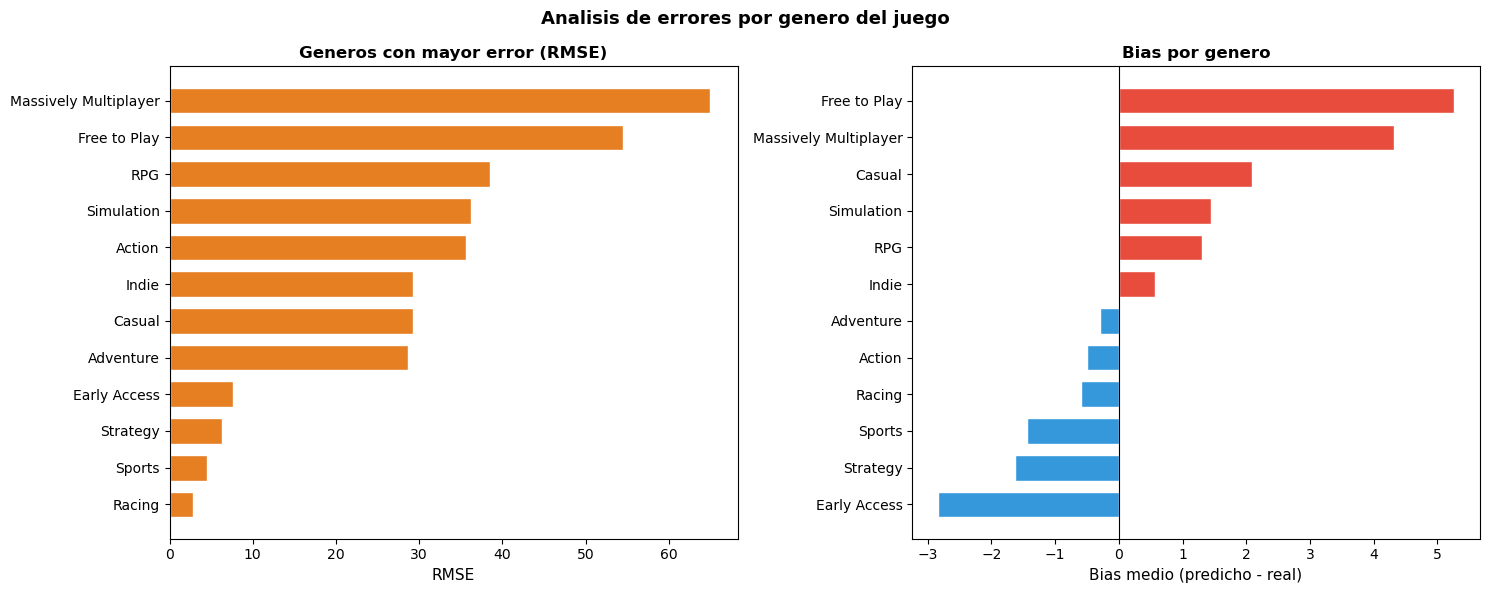

In [14]:
genre_map = df_games.set_index('item_idx')['genres'].to_dict()

if 'item_idx' in test_df.columns:
    test_df['genres_list'] = test_df['item_idx'].map(genre_map)
else:
    test_df['genres_list'] = None

genre_rows = []
for _, row in test_df.iterrows():
    genres = row.get('genres_list')
    if isinstance(genres, list):
        for g in genres:
            genre_rows.append({'genre': str(g), 'abs_err': row['abs_err'],
                               'error': row['error'], 'y_true': row['y_true']})

if genre_rows:
    genre_df = pd.DataFrame(genre_rows)
    genre_stats = genre_df.groupby('genre').agg(
        n=('y_true', 'count'),
        rmse=('error', lambda e: float(np.sqrt((e**2).mean()))),
        bias=('error', 'mean'),
    ).reset_index()
    genre_stats = genre_stats[genre_stats['n'] >= 5].sort_values('rmse', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    top_g = genre_stats.head(15)
    axes[0].barh(top_g['genre'][::-1], top_g['rmse'][::-1], color='#e67e22', edgecolor='white', height=0.7)
    axes[0].set_xlabel('RMSE', fontsize=11)
    axes[0].set_title('Generos con mayor error (RMSE)', fontsize=12, fontweight='bold')

    bias_g = genre_stats.sort_values('bias', ascending=False).head(15)
    bcols  = ['#e74c3c' if b > 0 else '#3498db' for b in bias_g['bias']]
    axes[1].barh(bias_g['genre'][::-1], bias_g['bias'][::-1], color=bcols[::-1], edgecolor='white', height=0.7)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Bias medio (predicho - real)', fontsize=11)
    axes[1].set_title('Bias por genero', fontsize=12, fontweight='bold')

    plt.suptitle('Analisis de errores por genero del juego', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No hay datos de genero disponibles en el set de test.')